In [1]:
import pandas as pd 
pd.read_json('train.json')

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ..."
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b..."
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli..."


In [3]:
pd.read_json('https://api.exchangerate-api.com/v4/latest/INR')

,provider,WARNING_UPGRADE_TO_V6,terms,base,date,time_last_updated,rates
INR,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,1.0000
AED,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.0385
AFN,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.6740
ALL,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.8670
AMD,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,3.8600
...,...,...,...,...,...,...,...
YER,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,2.5100
ZAR,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.1710
ZMW,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.1920
ZWG,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-07-03,1783036801,0.2820


# Fetch data using api

In [8]:
import pandas as pd
import requests
url =  "https://dummyjson.com/products"
response = requests.get(url)
df1 = pd.DataFrame(response.json()['products'])[['id', 'title' , 'category', 'price', 'rating','stock']]
df1

,id,title,category,price,rating,stock
0,1,Essence Mascara Lash Princess,beauty,9.99,2.56,99
1,2,Eyeshadow Palette with Mirror,beauty,19.99,2.86,34
2,3,Powder Canister,beauty,14.99,4.64,89
3,4,Red Lipstick,beauty,12.99,4.36,91
4,5,Red Nail Polish,beauty,8.99,4.32,79
5,6,Calvin Klein CK One,fragrances,49.99,4.37,29
6,7,Chanel Coco Noir Eau De,fragrances,129.99,4.26,58
7,8,Dior J'adore,fragrances,89.99,3.80,98
8,9,Dolce Shine Eau de,fragrances,69.99,3.96,4
9,10,Gucci Bloom Eau de,fragrances,79.99,2.74,91


# Fetch data using Web-scrape

In [17]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [23]:
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.14; rv:66.0) Gecko/20100101 Firefox/66.0"
}
webpage = requests.get("https://www.ambitionbox.com/list-of-companies?page=1",headers = headers).text

In [24]:
soup = BeautifulSoup(webpage, 'lxml')

In [32]:
# print(soup.prettify())
soup.find_all('h1')[0].text.strip()

'Top Companies in\n\t\t\t\t \n\t\t\t\t\tINDIA'

In [33]:
for i in soup.find_all('h2'):
    print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
HDB Financial Services
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


In [41]:
soup.find_all('div' , class_ = 'rating_text')

[<div class="rating_text rating_text--md"><div style="height:auto;">
 			3.3<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.7<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.6<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.7<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.6<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.8<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.5<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.4<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.9<!-- --></div></div>,
 <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.3<!-- --></div></div>,
 <div class="rating_

In [45]:
1

company=soup.find_all('div', class_ = 'companyCardWrapper')
len(company)

20

In [76]:
name = []
rating = []
reviews = []
salaries = []
interviews = []
jobs = []
for i in company:
    name.append(i.find('h2').text.strip())
    rating.append(i.find_all('div', class_ = 'rating_text')[0].text.strip())
    reviews.append(i.find('span', class_ = 'companyCardWrapper__ActionCount').text)
    action = i.find_all("span", class_="companyCardWrapper__ActionCount")
    salaries.append(action[1].text.strip())
    interviews.append(action[2].text.strip())
    jobs.append(action[3].text.strip())


In [74]:
name
rating
reviews
industry
salaries
interviews
jobs

['4.6k',
 '22.3k',
 '4.2k',
 '947',
 '2k',
 '255',
 '3.1k',
 '240',
 '11',
 '713',
 '647',
 '1.8k',
 '222',
 '--',
 '16',
 '74',
 '100',
 '75',
 '552',
 '4']

In [78]:
df = pd.DataFrame({
    "Company": name,
    "Rating": rating,
    "Reviews": reviews,
    "Salaries": salaries,
    "Interviews": interviews,
    "Jobs": jobs,
})
df

,Company,Rating,Reviews,Salaries,Interviews,Jobs
0,TCS,3.3,1.2L,10.3L,11.4k,4.6k
1,Accenture,3.7,75k,7.1L,9.5k,22.3k
2,Wipro,3.6,66.2k,4.9L,6.9k,4.2k
3,Cognizant,3.7,62.5k,6.1L,6.5k,947
4,Capgemini,3.6,54.6k,4.9L,5.6k,2k
5,HDFC Bank,3.8,53.7k,1.5L,3.1k,255
6,Infosys,3.5,49.8k,5.3L,8.5k,3.1k
7,HCLTech,3.4,46.9k,3.9L,4.6k,240
8,ICICI Bank,3.9,46.7k,1.6L,3k,11
9,Tech Mahindra,3.3,44.2k,2.9L,4.7k,713


# Understand the data 


In [2]:
import pandas as pd
df =pd.read_csv('HousePrices.csv')

# 1. How big is the data?

In [3]:
df.shape

(4600, 18)

# 2. How does the data look like?

In [4]:
df.sample(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1107,2014-05-21 00:00:00,1220000.0,4.0,2.50,3240,3600,2.0,0,0,3,2060,1180,2008,0,2433 1st Ave N,Seattle,WA 98109,USA
1239,2014-05-23 00:00:00,1050000.0,3.0,4.00,4380,42769,2.0,0,0,5,4380,0,1983,0,17301 NE 131st St,Redmond,WA 98052,USA
2689,2014-06-17 00:00:00,465000.0,2.0,2.75,1430,1425,2.0,0,0,3,995,435,2006,0,224 26th Ave E,Seattle,WA 98112,USA
3598,2014-06-27 00:00:00,415000.0,3.0,2.75,2600,64626,1.5,0,0,3,2600,0,2009,0,69506 NE Money Creek Rd,Skykomish,WA 98288,USA
4457,2014-06-04 00:00:00,557125.0,4.0,2.75,3370,12447,2.0,0,0,3,3370,0,1991,0,14257 212th Dr NE,Woodinville,WA 98077,USA


# 3. What is the data type of cols

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

# 4.Are there any missing value?

In [6]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

# 5. How does the data look mathematically?

In [7]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# 6. Are there duplicaate values?

In [8]:
df.duplicated().sum()

np.int64(0)

# 7. How is the correlation between cols?

In [10]:
# df.corr()

# EDA using Unovariate

In [2]:
import pandas as pd
df = pd.read_csv('train.csv')
import seaborn as sns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: xlabel='Pclass'>

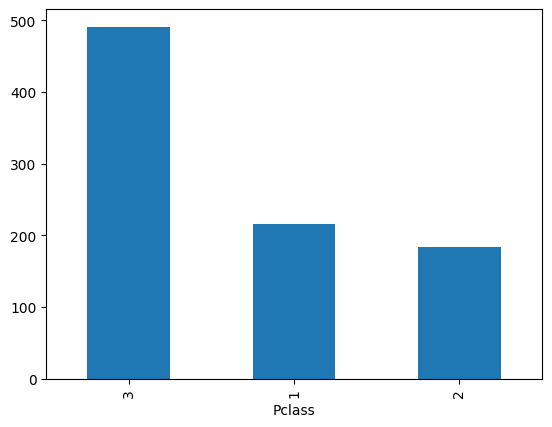

In [5]:
# sns.countplot(df['Survived'])
# df['Survived'].value_counts().plot(kind = 'bar')
df['Pclass'].value_counts().plot(kind = 'bar')